In [12]:
import os
import glob
import nibabel as nib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
import os
import glob
import nibabel as nib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
import concurrent.futures
import threading

In [13]:
#ROOT_DIR = "/bettik/PROJECTS/pr-gin5_aini/fehrdelt/"
#ROOT_DIR = /home/theotime/bettik/
ROOT_DIR = "/home/fehrdelt/bettik/"

In [14]:

final_t1_dataset_small_ixi = ROOT_DIR+"datasets/final_t1_dataset_small/ixi_registered/"
final_t1_dataset_small_oasis = ROOT_DIR+"datasets/final_t1_dataset_small/oasis_registered/"
final_t1_dataset_small_dallas = ROOT_DIR+"datasets/final_t1_dataset_small/dallas_registered/"

In [15]:


def analyze_folder(folder_path):
    nifti_files = glob.glob(os.path.join(folder_path, '*.nii*'))
    print(f"Found {len(nifti_files)} NIfTI files.")
    
    if len(nifti_files) == 0:
        return pd.DataFrame()
    
    # 1. Compute the mean image of the folder to use as a reference for PSNR / MSE
    print("Computing mean image reference...")
    
    # Mutable containers so they can be modified inside the worker thread
    mean_img_container = {'data': None}
    count = 0
    valid_shape = None
    lock = threading.Lock()
    
    def process_file_mean(file):
        nonlocal count, valid_shape
        try:
            data = nib.load(file).get_fdata()
            with lock:
                if mean_img_container['data'] is None:
                    mean_img_container['data'] = np.zeros_like(data)
                    valid_shape = data.shape
                
                if data.shape == valid_shape:
                    mean_img_container['data'] += data
                    count += 1
                else:
                    return f"Warning: {os.path.basename(file)} has unexpected shape {data.shape}"
        except Exception as e:
            return f"Error loading {file}: {e}"

    with concurrent.futures.ThreadPoolExecutor() as executor:
        # executor.map maintains order, we use tqdm for progress bar
        results = list(tqdm(executor.map(process_file_mean, nifti_files), total=len(nifti_files), desc="Step 1/2: Mean Image"))
        
    for res in results:
        if res is not None:
            print(res)
            
    if count > 0:
        mean_img_container['data'] /= count
        
    mean_img = mean_img_container['data']
        
    # 2. Compute metrics for each image
    print("Computing metrics for each image...")
    metrics_list = []
    
    def process_file_metrics(file):
        try:
            data = nib.load(file).get_fdata()
            
            # Basic intensity metrics
            mean_val = np.mean(data)
            std_val = np.std(data)
            min_val = np.min(data)
            max_val = np.max(data)
            
            # PSNR against the mean image
            psnr = np.nan
            if mean_img is not None and data.shape == valid_shape:
                mse = np.mean((data - mean_img) ** 2)
                if mse > 0:
                    max_pixel = np.max(data) if np.max(data) > 0 else 1.0 # avoid div by zero
                    psnr = 20 * np.log10(max_pixel / np.sqrt(mse))
                else:
                    psnr = float('inf')
                    
            return {
                'filename': os.path.basename(file),
                'mean': mean_val,
                'std': std_val,
                'min': min_val,
                'max': max_val,
                'psnr_vs_mean': psnr
            }
        except Exception as e:
            return None

    with concurrent.futures.ThreadPoolExecutor() as executor:
        for res in tqdm(executor.map(process_file_metrics, nifti_files), total=len(nifti_files), desc="Step 2/2: Metrics"):
            if res is not None:
                metrics_list.append(res)
            
    df = pd.DataFrame(metrics_list)
    return df


Found 581 NIfTI files.
Computing mean image reference...


Step 1/2: Mean Image:   0%|          | 0/581 [00:00<?, ?it/s]

Computing metrics for each image...


Step 2/2: Metrics:   0%|          | 0/581 [00:00<?, ?it/s]

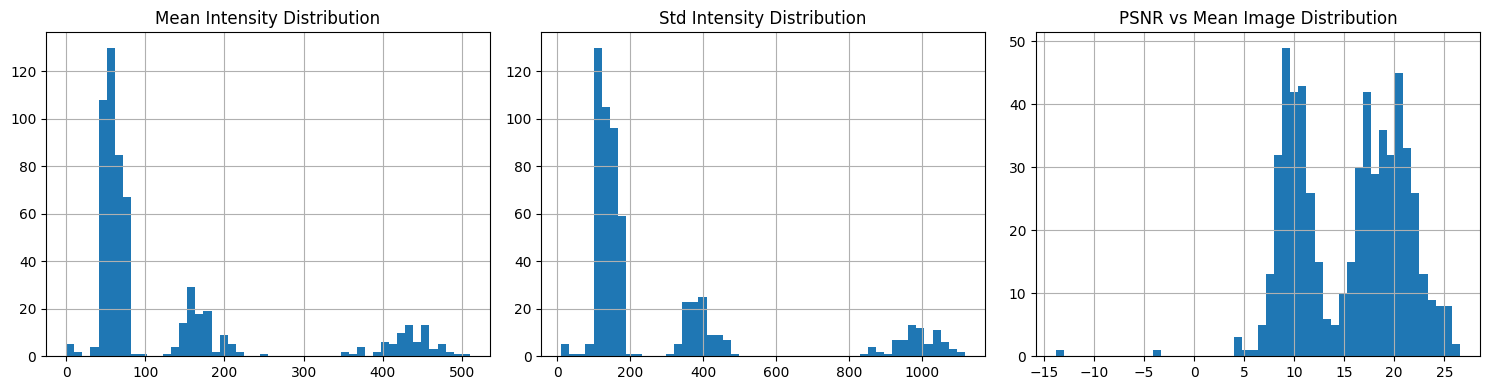

Possible outliers ( lowest PSNR, which might indicate bad registration ):


,filename,mean,std,min,max,psnr_vs_mean
308,IXI533-Guys-1066-T1.nii.gz,5.436582,12.924626,-4.353259,60.008957,-13.770745
426,IXI630-Guys-1108-T1.nii.gz,14.325928,33.804007,-18.961948,179.920380,-3.548481
267,IXI648-Guys-1107-T1.nii.gz,36.004570,84.798243,-34.929359,357.199219,4.247331
51,IXI285-Guys-0857-T1.nii.gz,1.030480,18.659511,-23.475887,501.309143,4.333687
15,IXI640-Guys-1106-T1.nii.gz,0.650906,14.331365,-17.457638,528.787842,4.779006
180,IXI090-Guys-0800-T1.nii.gz,12.648046,63.590505,-43.236443,488.295685,4.873951
112,IXI534-Guys-1062-T1.nii.gz,36.798876,90.287343,-42.907196,408.971619,5.595703
488,IXI102-HH-1416-T1.nii.gz,0.543569,15.463307,-19.952478,650.976013,6.577117
493,IXI157-Guys-0816-T1.nii.gz,46.138395,106.164318,-44.784863,421.709412,6.657575
75,IXI196-Guys-0805-T1.nii.gz,45.545676,104.122901,-46.015427,442.015961,6.971932


In [16]:

# Analyze one of the folders
folder_to_analyze = final_t1_dataset_small_ixi
df_metrics = analyze_folder(folder_to_analyze)

# Visualize distributions to spot outliers
if not df_metrics.empty:
    fig, axs = plt.subplots(1, 3, figsize=(15, 4))
    df_metrics['mean'].hist(ax=axs[0], bins=50)
    axs[0].set_title('Mean Intensity Distribution')
    
    df_metrics['std'].hist(ax=axs[1], bins=50)
    axs[1].set_title('Std Intensity Distribution')
    
    df_metrics['psnr_vs_mean'].hist(ax=axs[2], bins=50)
    axs[2].set_title('PSNR vs Mean Image Distribution')
    
    plt.tight_layout()
    plt.show()
    
    print("Possible outliers ( lowest PSNR, which might indicate bad registration ):")
    display(df_metrics.sort_values('psnr_vs_mean').head(10))

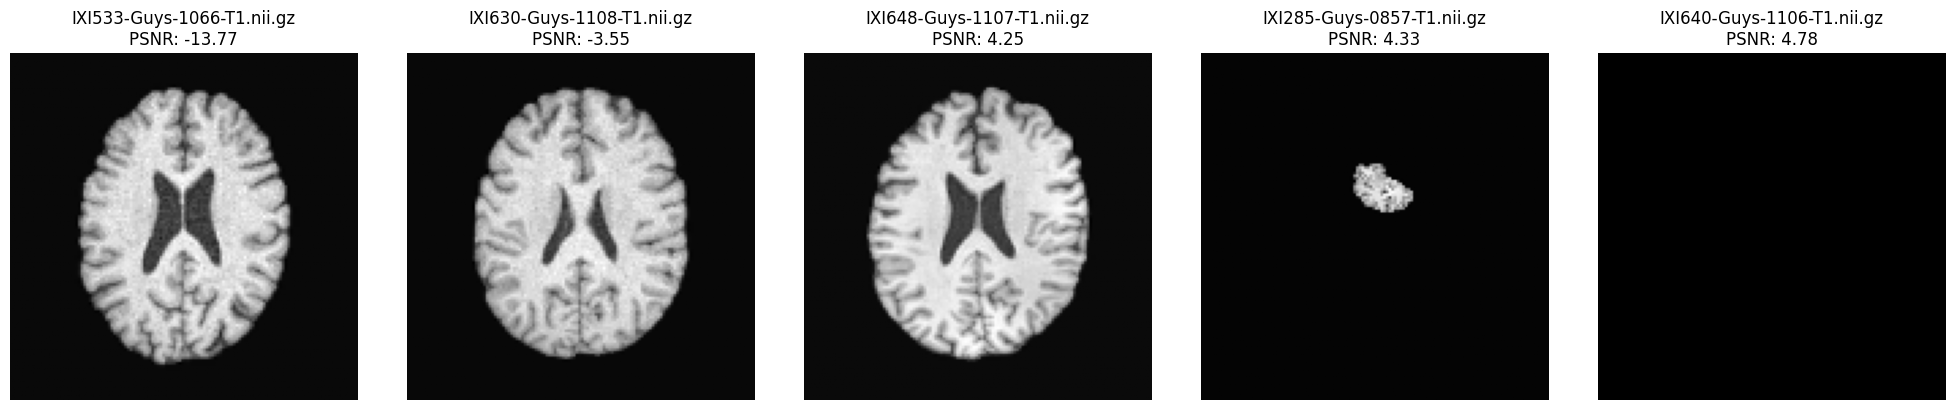

In [17]:
num_outliers = 5
outlier_files = df_metrics.sort_values('psnr_vs_mean').head(num_outliers)

fig, axes = plt.subplots(1, num_outliers, figsize=(20, 4))
if num_outliers == 1:
    axes = [axes]

for ax, (_, row) in zip(axes, outlier_files.iterrows()):
    filepath = os.path.join(folder_to_analyze, row['filename'])
    try:
        data = nib.load(filepath).get_fdata()
        # Usually, the 3rd dimension is the axial plane in NIfTI files
        mid_slice = data.shape[2] // 2
        
        # Transpose and use origin='lower' for correct anatomical orientation 
        ax.imshow(data[:, :, mid_slice].T, cmap='gray', origin='lower')
        ax.set_title(f"{row['filename']}\nPSNR: {row['psnr_vs_mean']:.2f}")
        ax.axis('off')
    except Exception as e:
        ax.set_title("Error loading image")
        ax.axis('off')
        print(f"Could not load {filepath}: {e}")

plt.tight_layout()
plt.show()